In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# ================================================
# 1. LOAD DATA
# ================================================

BASE_PATH = "/kaggle/input/competitions/telecom-customer-churn-data-quality-challenge"

customer = pd.read_csv(f"{BASE_PATH}/customer_info.csv")
churn = pd.read_csv(f"{BASE_PATH}/churn_labels.csv")
usage = pd.read_csv(f"{BASE_PATH}/usage_data.csv")

print("Loaded:")
print(" customer:", customer.shape)
print(" churn:", churn.shape)
print(" usage:", usage.shape)

# ================================================
# 2. FIX DUPLICATE CUSTOMER IDs
# ================================================

customer = customer.drop_duplicates(subset="CustomerID", keep="first")
print("customer after dedupe:", customer.shape)

# ================================================
# 3. CLEAN CUSTOMER
# ================================================

customer["Age"] = customer["Age"].replace(0, np.nan).fillna(customer["Age"].median())
customer["MonthlyCharges"] = customer["MonthlyCharges"].clip(5, 200)
customer["SignupDate"] = pd.to_datetime(customer["SignupDate"], errors="coerce")

SNAPSHOT = pd.to_datetime("2024-01-01")
customer["TenureMonths"] = ((SNAPSHOT - customer["SignupDate"]).dt.days // 30).clip(lower=1)

# ================================================
# 4. AGGREGATE USAGE DATA
# ================================================

usage = usage.drop_duplicates()

usage_numeric = usage.select_dtypes(include=[np.number]).columns.tolist()
usage_numeric = [c for c in usage_numeric if c != "CustomerID"]

usage_agg = usage.groupby("CustomerID")[usage_numeric].agg(
    ["mean", "sum", "max", "min", "std"]
)

usage_agg.columns = ["_".join(col) for col in usage_agg.columns]
usage_agg = usage_agg.reset_index()

print("usage aggregated:", usage_agg.shape)

# ================================================
# 5. MERGE TRAIN SET
# ================================================

df = churn.merge(customer, on="CustomerID", how="left")
df = df.merge(usage_agg, on="CustomerID", how="left")

print("AFTER MERGE:", df.shape)

# ================================================
# 6. FEATURE ENGINEERING
# ================================================

df["Age_x_Charges"] = df["Age"] * df["MonthlyCharges"]
df["ChargesPerTenure"] = df["MonthlyCharges"] * df["TenureMonths"]

df = df.drop(columns=["SignupDate"], errors="ignore")

print("Train DF:", df.shape)

# ================================================
# 7. TRAIN/VAL SPLIT
# ================================================

X = df.drop(["CustomerID", "Churn"], axis=1)
y = df["Churn"]

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train/Val split OK")

# ================================================
# 8. TRAIN CATBOOST
# ================================================

model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_cols,
    verbose=False
)

preds_val = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, preds_val)

print("Validation AUC:", auc)

# ================================================
# 9. BUILD TEST SET
# ================================================

df_test = churn[["CustomerID"]].merge(customer, on="CustomerID", how="left")
df_test = df_test.merge(usage_agg, on="CustomerID", how="left")

df_test["Age_x_Charges"] = df_test["Age"] * df_test["MonthlyCharges"]
df_test["ChargesPerTenure"] = df_test["MonthlyCharges"] * df_test["TenureMonths"]

df_test = df_test.drop(columns=["SignupDate"], errors="ignore")

preds = model.predict_proba(df_test.drop(["CustomerID"], axis=1))[:, 1]

submission = pd.DataFrame({
    "CustomerID": df_test["CustomerID"],
    "ChurnProbability": preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv saved!")

# ================================================
# 10. VERIFY
# ================================================

sub = pd.read_csv("submission.csv")
print("Rows:", len(sub))
print("Unique IDs:", sub["CustomerID"].nunique())


Loaded:
 customer: (10200, 7)
 churn: (10000, 2)
 usage: (120000, 6)
customer after dedupe: (10000, 7)
usage aggregated: (10000, 21)
AFTER MERGE: (10000, 29)
Train DF: (10000, 30)
Train/Val split OK
Validation AUC: 0.5442904983912272
submission.csv saved!
Rows: 10000
Unique IDs: 10000


In [2]:
customer = customer.drop_duplicates(subset="CustomerID", keep="first")

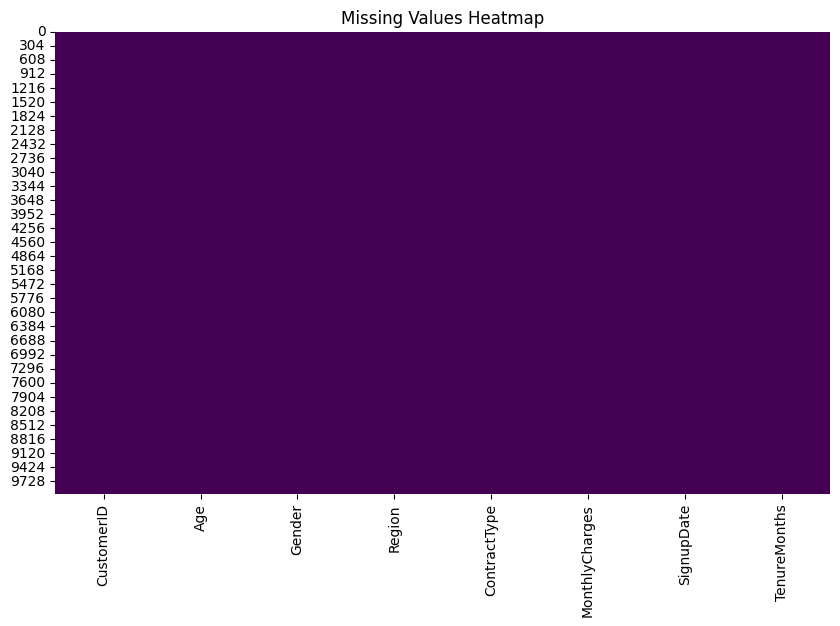

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(customer.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()


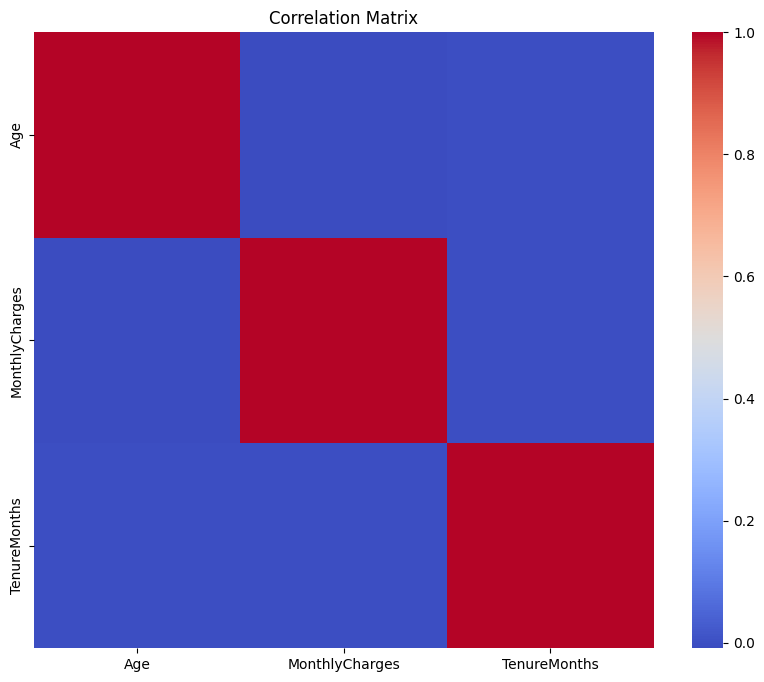

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(customer.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
